In [1]:
%load_ext autoreload
%autoreload 2
    
import polars as pl
from pathlib import Path
from tqdm.notebook import tqdm
import numpy as np
import sys
from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib_config import rcparams
mpl.rcParams.update(rcparams)
import jax
from jax import numpy as jnp
from jax import random
from functools import partial
jax.config.update("jax_enable_x64", True)

sys.path.append('../src')
from robust_periodicity import clean_light_curve, unpack_light_curve
from robust_periodicity import fit_sine_wave, fourier_series_mean_function

/home/pabloh/work/GASP/.venv/lib/python3.12/site-packages/astropy/config/paths.py:55: AstropyUserWarning: XDG_CONFIG_HOME is set to '/home/pabloh/.config', but the default location, /home/pabloh/.astropy/config, already exists, and takes precedence. This environment variable will be ignored.
  return set_temp_config._get_dir_path(rootname)


# Finding significant periodicities (MCMC-based)

The following presumes that the data was downloaded and that `periodogram_maxima`, `red_noise_laplace` and `p_value_laplace` have finished for the given experiment.

In [2]:
fbin = 0 
experiment = 'candidates_run_laplace'
significance = 1e-5
data_folder = Path('../data/') / experiment
result_folder = Path('../results/') / experiment

How many are significant under both both the exponential kernel GP (damped random walk) and the powered exponential when MCMC is used to fit the posteriors?

In [3]:
# How many are significant according to the DRW empirical p-values 
df_above_critical = pl.scan_parquet(result_folder / 'periodogram_maxima').join(
    pl.scan_parquet(result_folder / 'pval_mc_laplace').filter(pl.col('p_values').list.get(fbin).lt(significance)).select('sourceid'), on='sourceid'
).join(
    pl.scan_parquet(result_folder / 'pval_mc_mcmc').filter(pl.col('p_values').list.get(fbin).lt(significance)).select('sourceid'), on='sourceid', 
).join(
    pl.scan_parquet(result_folder / 'pval_mc_mcmcgamma').filter(pl.col('p_values').list.get(fbin).lt(significance)).select('sourceid'), on='sourceid', suffix='_gamma'
).with_columns(
    (1.0/pl.col('top_frequency').list.get(fbin)).alias('dominant_period'),
).with_columns(
    (pl.col('time_duration').truediv('dominant_period')).alias('num_cycles')
).collect()
df_above_critical.height

13

And only 1 has a period that is below 1.5 cycles per day

In [4]:
df_above_critical.with_columns(
    pl.col('num_cycles').cut([3, 1.5, 0], left_closed=True)
).group_by('num_cycles').len().sort('num_cycles')

num_cycles,len
cat,u32
"""[0, 1.5)""",12
"""[1.5, 3)""",1


Plotting the candidates

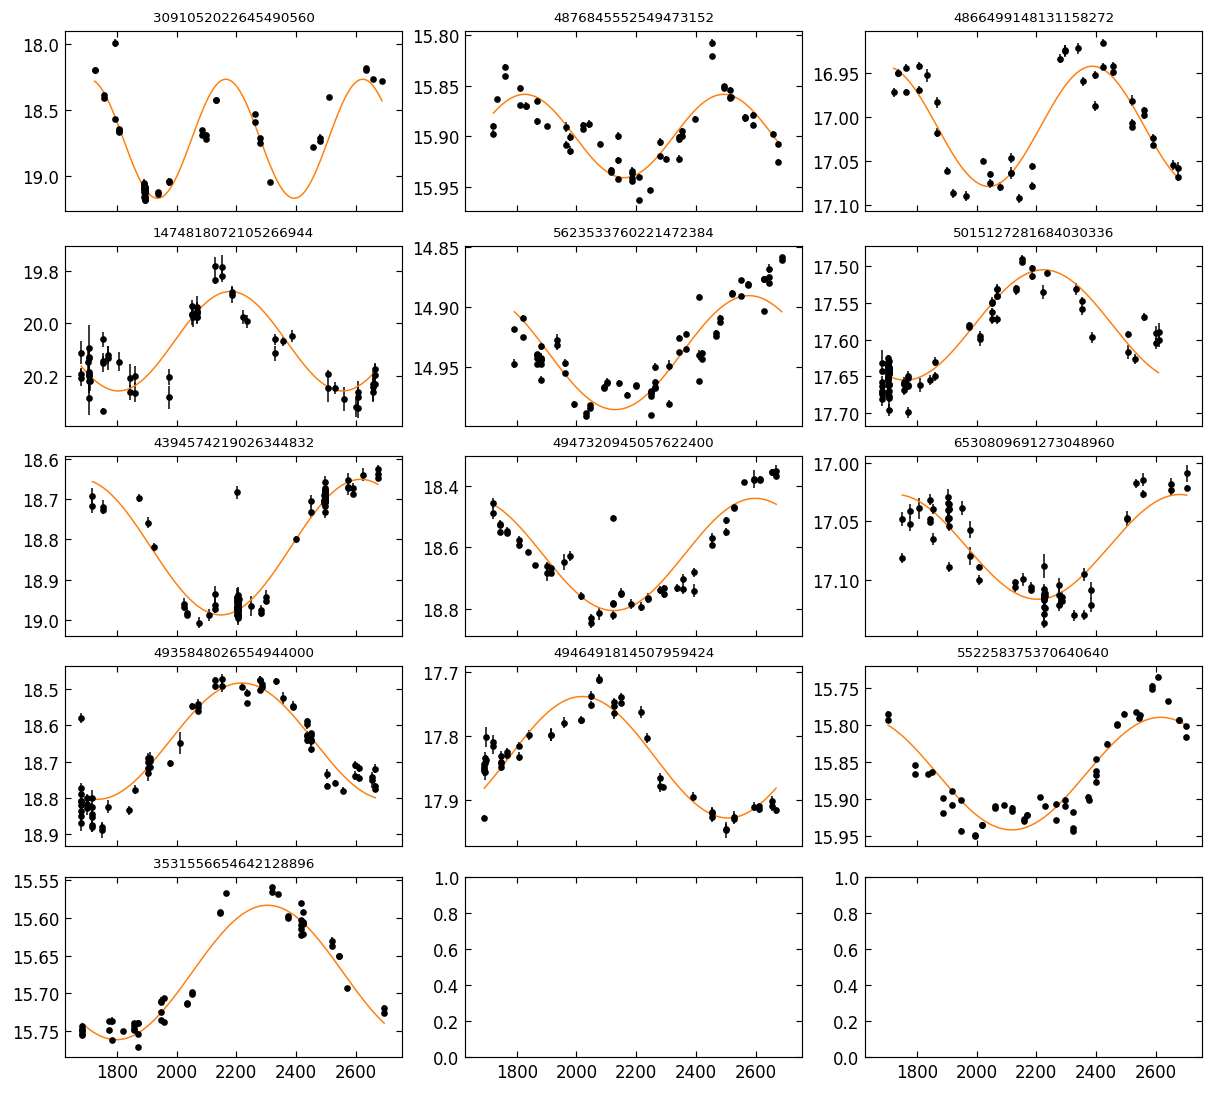

In [5]:
fig, axs = plt.subplots(5, 3, figsize=(10, 9), sharex=True, constrained_layout=True, dpi=120)

def get_light_curve(sid):
    return pl.scan_parquet(data_folder / 'part_*.parquet').filter(pl.col('sourceid').eq(sid)).collect()

def fitted_sine_wave_model(time, mag, err, best_period):
    params = fit_sine_wave(time, mag, err, best_period, return_params=True)[1]
    return partial(fourier_series_mean_function, params=params, period=best_period, n_harmonics=1)

    
for k, ax, in enumerate(axs.ravel()):
    ex = df_above_critical.sort('dominant_period').slice(k, 1)
    if ex.height == 0:
        continue
    sid = ex['sourceid'].item()
    best_period = ex['dominant_period'].item()
    lc = clean_light_curve(unpack_light_curve(get_light_curve(sid)), remove_extreme_errors=True, remove_extreme_values=True)
    time, mag, err = lc['g']
    time_interp = jnp.linspace(jnp.amin(time), jnp.amax(time), 500)
    per_model = jax.vmap(fitted_sine_wave_model(time, mag, err, best_period))(time=time_interp)
    ax.errorbar(time, mag, err, fmt='.', c='k')
    ax.invert_yaxis()
    ax.plot(time_interp, per_model, color='C1')
    ax.set_title(sid, fontsize=8)

Preparing summaries

In [6]:
param_cols = ["log_sigma", "log_tau", "mean", "logit_gamma"]

exprs = [pl.col("sourceid")]
for param in param_cols:
    col = pl.col(param)
    phys_name = param
    if 'log_' in param:
        col = col.list.eval(pl.element().exp())
        phys_name = param.removeprefix("log_")
    if 'logit_' in param:
        col = col.list.eval(
            pl.lit(1.0) + pl.lit(1.0) / (pl.lit(1.0) + (-pl.element()).exp())
        )
        phys_name = param.removeprefix("logit_")
    q16 = col.list.eval(pl.element().quantile(0.16)).list.first()
    q50 = col.list.eval(pl.element().quantile(0.50)).list.first()
    q84 = col.list.eval(pl.element().quantile(0.84)).list.first()
    
    exprs.extend([
        q50.alias(f"{phys_name}_med"),
        (q84 - q50).alias(f"{phys_name}_upper"),
        (q50 - q16).alias(f"{phys_name}_lower"),
    ])

summary = pl.scan_parquet(result_folder / 'red_noise_mcmcgamma' / 'part_*.parquet').select(exprs).join(
    df_above_critical.select(['sourceid', 'num_obs', 'magnitude_mean', 'magnitude_std', 'dominant_period']).lazy(), on='sourceid'
).join(
    pl.scan_parquet('../data/gaia_qso_initial_selection_40obs_500d.parquet').select(['sourceid', 'ra', 'dec']), on='sourceid'
).sort('dominant_period').collect()
summary.write_csv('../results/final_candidate_list.csv')
summary

sourceid,sigma_med,sigma_upper,sigma_lower,tau_med,tau_upper,tau_lower,mean_med,mean_upper,mean_lower,gamma_med,gamma_upper,gamma_lower,num_obs,magnitude_mean,magnitude_std,dominant_period,ra,dec
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64
3091052022645490560,0.398276,0.082489,0.060945,2.05484,1.108594,0.684912,18.629194,0.088577,0.090031,1.111914,0.082894,0.051261,55,18.797539,0.339807,458.624,122.293397,2.930228
4876845552549473152,0.039112,0.006574,0.005139,1.430031,0.767248,0.49493,15.894291,0.00721,0.007231,1.140937,0.103034,0.065666,56,15.893653,0.033728,666.63995,76.079326,-29.744199
4866499148131158272,0.069048,0.012301,0.009437,1.77024,1.151281,0.700586,17.006137,0.013248,0.013233,1.160386,0.128594,0.077334,44,17.002811,0.055836,694.676958,69.227071,-37.260755
1474818072105266944,0.166179,0.030268,0.023281,1.670632,1.064123,0.631364,20.116276,0.032308,0.032764,1.120814,0.086773,0.055383,63,20.117668,0.144103,750.916959,199.753628,37.73721
5623533760221472384,0.042366,0.006888,0.005357,0.905318,0.418654,0.277577,14.934965,0.007583,0.0076,1.124005,0.088897,0.057118,70,14.934644,0.035987,895.944616,139.778707,-35.640843
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
6530809691273048960,0.047032,0.008984,0.006687,1.722402,1.009632,0.607197,17.072197,0.009383,0.009541,1.104968,0.074297,0.047351,65,17.077135,0.038286,952.797321,359.538444,-46.083572
4935848026554944000,0.148083,0.023023,0.01824,1.873228,0.925707,0.594084,18.66702,0.026295,0.026287,1.093839,0.062812,0.041154,77,18.686024,0.127415,968.811382,22.505103,-42.672306
4946491814507959424,0.07862,0.014359,0.011046,2.133849,1.313281,0.79422,17.836132,0.015352,0.015451,1.113874,0.079269,0.051706,54,17.83767,0.064513,977.681752,36.822488,-44.557144


Appendix table

In [7]:
header = " & ".join(["Source ID", "RA [deg]", "Dec [deg]", "Period [d]"]) + r" \\"

print(r"\begin{table}")
print(r"\centering")
print(r"\caption{Dominant periods of candidate periodic sources.}")
print(r"\label{tab:candidates}")
print(r"\begin{tabular}{lccc}")
print(r"\hline\hline")
print(header)
print(r"\hline")

for row in summary.select(['sourceid', 'ra', 'dec', 'dominant_period']).sort('dominant_period').iter_rows(named=True):
    cols = [
        str(row["sourceid"]),
        f"${row['ra']:.4f}$",
        f"${row['dec']:.4f}$",
        f"${row['dominant_period']:.1f}$",
    ]
    print(" & ".join(cols) + r" \\")

print(r"\hline")
print(r"\end{tabular}")
print(r"\end{table}")

\begin{table}
\centering
\caption{Dominant periods of candidate periodic sources.}
\label{tab:candidates}
\begin{tabular}{lccc}
\hline\hline
Source ID & RA [deg] & Dec [deg] & Period [d] \\
\hline
3091052022645490560 & $122.2934$ & $2.9302$ & $458.6$ \\
4876845552549473152 & $76.0793$ & $-29.7442$ & $666.6$ \\
4866499148131158272 & $69.2271$ & $-37.2608$ & $694.7$ \\
1474818072105266944 & $199.7536$ & $37.7372$ & $750.9$ \\
5623533760221472384 & $139.7787$ & $-35.6408$ & $895.9$ \\
5015127281684030336 & $21.6353$ & $-34.0981$ & $926.0$ \\
4394574219026344832 & $258.5679$ & $7.1703$ & $937.8$ \\
4947320945057622400 & $42.3668$ & $-43.8540$ & $948.9$ \\
6530809691273048960 & $359.5384$ & $-46.0836$ & $952.8$ \\
4935848026554944000 & $22.5051$ & $-42.6723$ & $968.8$ \\
4946491814507959424 & $36.8225$ & $-44.5571$ & $977.7$ \\
552258375370640640 & $79.9643$ & $76.9335$ & $998.9$ \\
3531556654642128896 & $170.7595$ & $-27.5012$ & $1013.0$ \\
\hline
\end{tabular}
\end{table}
